Import the chosen model

In [ ]:
import sys
import os
import pandas as pd

# Add the absolute path to the scripts folder
scripts_path = os.path.abspath("../scripts")
sys.path.append(scripts_path)

from utils import load_model
from evaluation import error_analysis_loop


In [ ]:
test_unprocessed = pd.read_csv("../data/interim/test_unprocessed.csv")
test_final = pd.read_csv("../data/processed/test_processed.csv")

In [ ]:
X_test= test_final.drop(columns=["y"])
y_test = test_final["y"]   

In [ ]:
models_dir = os.path.abspath("../models")



logreg_model = load_model("LogisticRegression", models_dir)

✅ Loaded LogisticRegression from c:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\models\LogisticRegression.pkl


### Error Analysis

In [ ]:
y_pred =logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]


In [ ]:
# Building dataset
error_df = test_unprocessed.copy()
error_df["target"] = y_test
error_df["predicted"] = y_pred
error_df["predicted_proba"] = y_proba
error_df["match"] = (y_test == y_pred).astype(int)
error_df["diff"] = y_test - y_proba



In [ ]:
error_df

,job,marital,education,housing,loan,contact,month,day_of_week,age,pdays,emp_var_rate,cons_conf_idx,age_group,housing_loan_interaction,target,predicted,predicted_proba,match,diff
0,blue-collar,married,high.school,no,no,cellular,may,tue,33,999,-1.8,-46.2,adult,no_no,0,1,0.540798,0,-0.540798
1,admin.,married,university.degree,no,no,cellular,may,tue,39,999,-1.8,-46.2,adult,no_no,0,1,0.551772,0,-0.551772
2,services,single,university.degree,yes,no,cellular,may,tue,32,999,-1.8,-46.2,adult,yes_no,0,1,0.548660,0,-0.548660
3,admin.,divorced,high.school,no,no,cellular,may,tue,47,999,-1.8,-46.2,adult,no_no,0,0,0.417534,1,-0.417534
4,technician,married,university.degree,unknown,unknown,cellular,may,tue,43,999,-1.8,-46.2,adult,unknown_unknown,1,0,0.394759,0,0.605241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7738,retired,married,professional.course,yes,no,cellular,nov,fri,73,999,-1.1,-50.8,senior,yes_no,1,0,0.399651,0,0.600349
7739,blue-collar,married,professional.course,no,no,cellular,nov,fri,46,999,-1.1,-50.8,adult,no_no,0,0,0.321477,1,-0.321477
7740,retired,married,university.degree,yes,no,cellular,nov,fri,56,999,-1.1,-50.8,senior,yes_no,0,1,0.524678,0,-0.524678
7741,technician,married,professional.course,no,no,cellular,nov,fri,44,999,-1.1,-50.8,adult,no_no,1,0,0.307206,0,0.692794


In [ ]:
numerical_columns = error_df.select_dtypes(include=['number'])
categorical_columns = error_df.select_dtypes(include=['object', 'category'])


Match rate by job:
          job    match
       admin. 0.437195
  blue-collar 0.421191
 entrepreneur 0.514286
    housemaid 0.600000
   management 0.446429
      retired 0.450626
self-employed 0.516129
     services 0.511265
      student 0.435798
   technician 0.481647
   unemployed 0.534884
      unknown 0.409836

Match rate by contact:
  contact    match
 cellular 0.449514
telephone 0.531085

Match rate by month:
month    match
  apr 0.566474
  aug 0.425381
  dec 0.508772
  jul 0.504098
  jun 0.396980
  mar 0.568182
  may 0.464461
  nov 0.513514
  oct 0.420063
  sep 0.456483

Match rate by education:
          education    match
           basic.4y 0.580175
           basic.6y 0.371134
           basic.9y 0.428571
        high.school 0.478004
         illiterate 0.500000
professional.course 0.520790
  university.degree 0.404540
            unknown 0.518987

Match rate by age_group:
age_group    match
    adult 0.456900
  elderly 0.531532
   senior 0.471580
    youth 0.418288

Matc

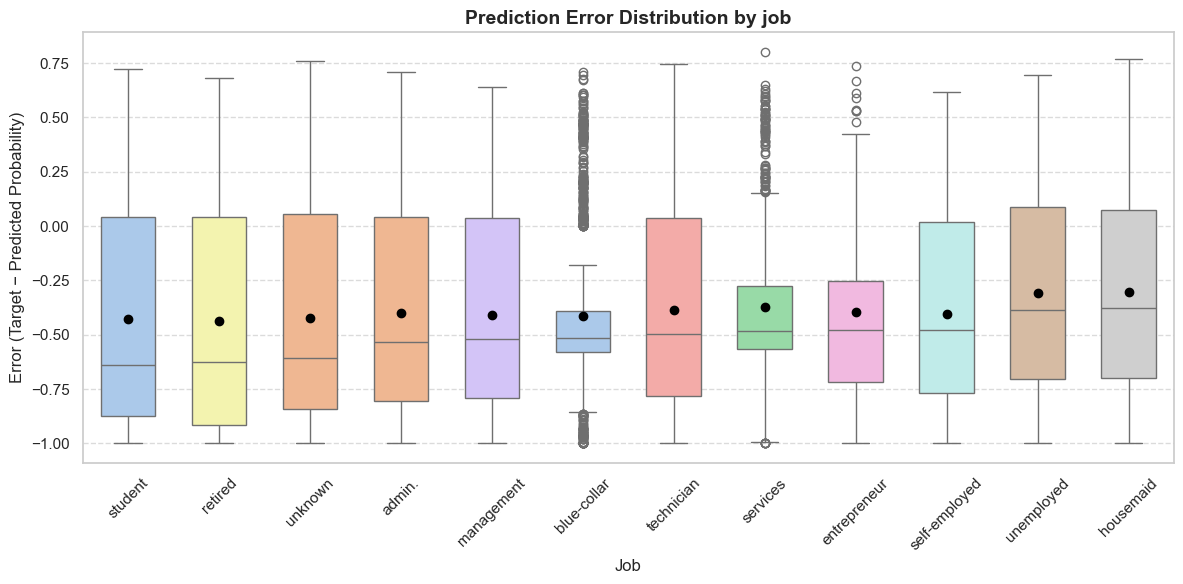

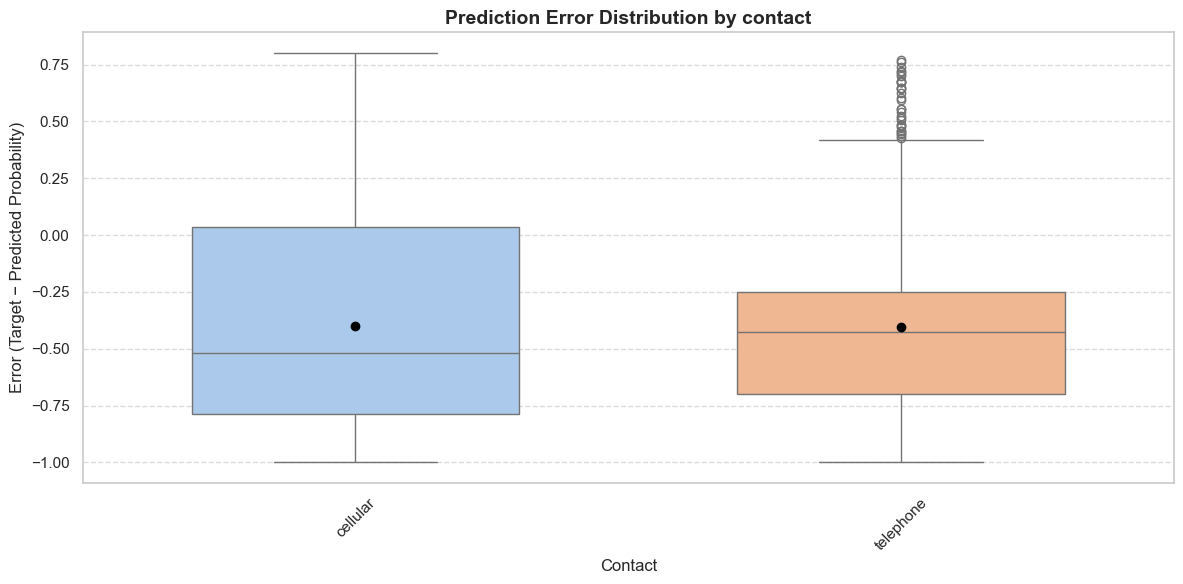

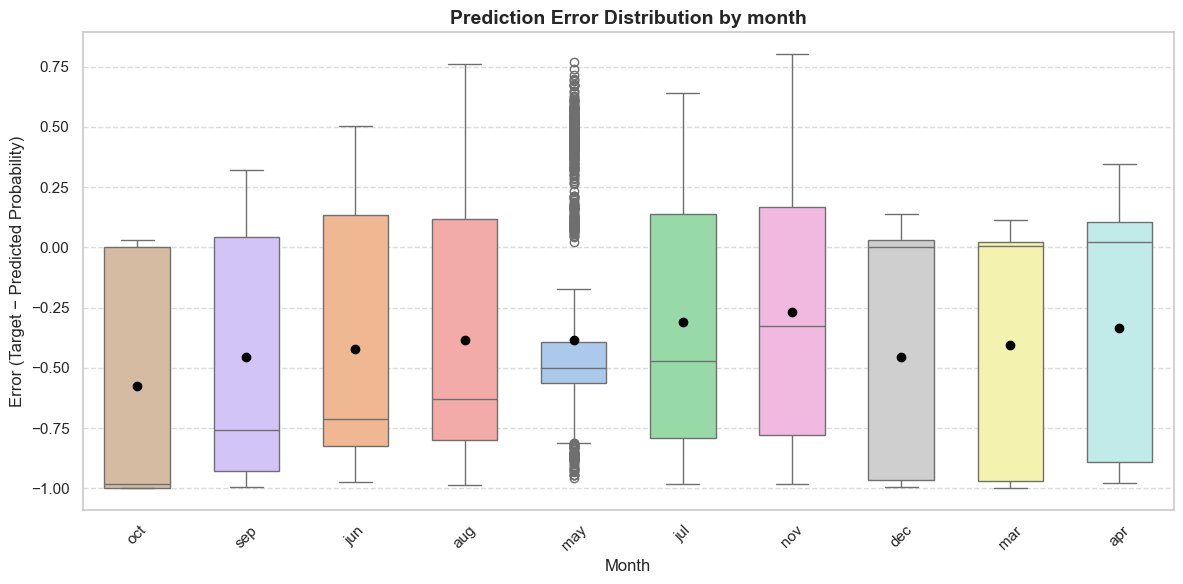

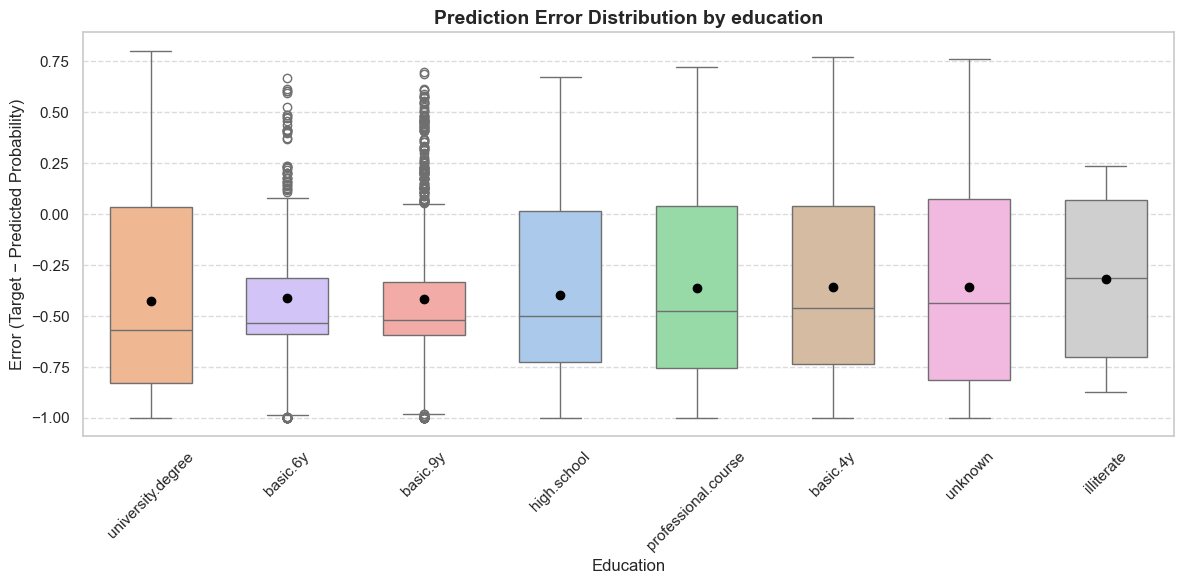

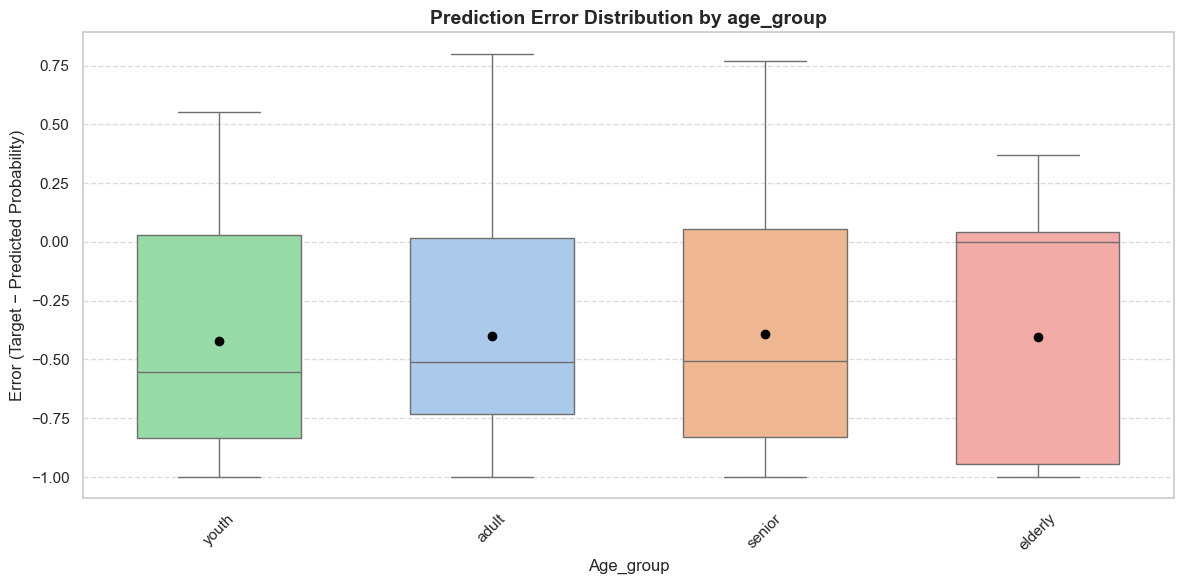

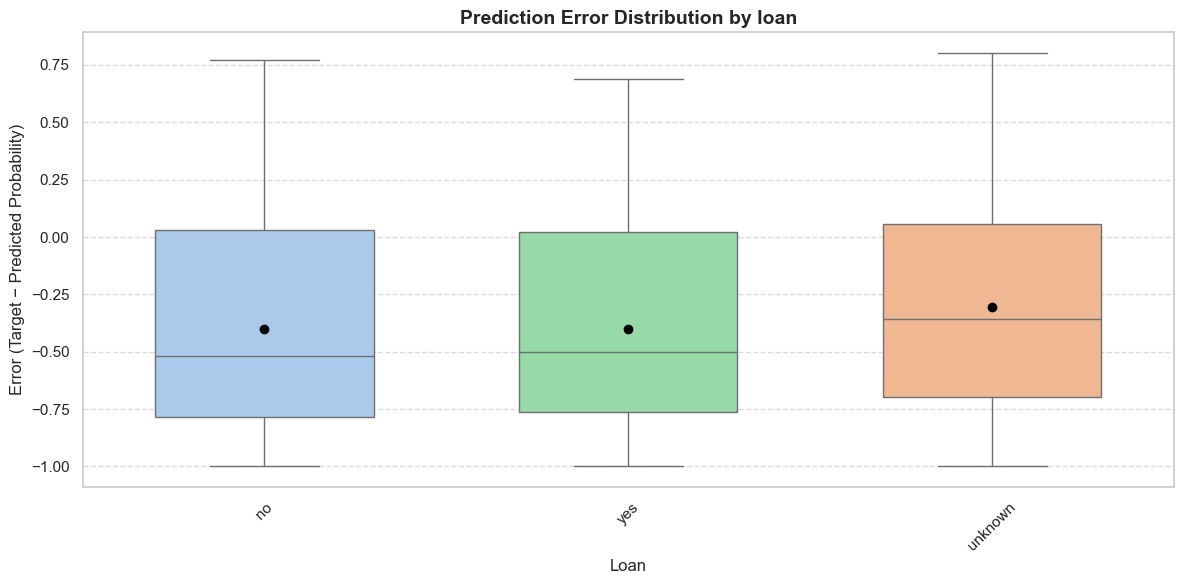

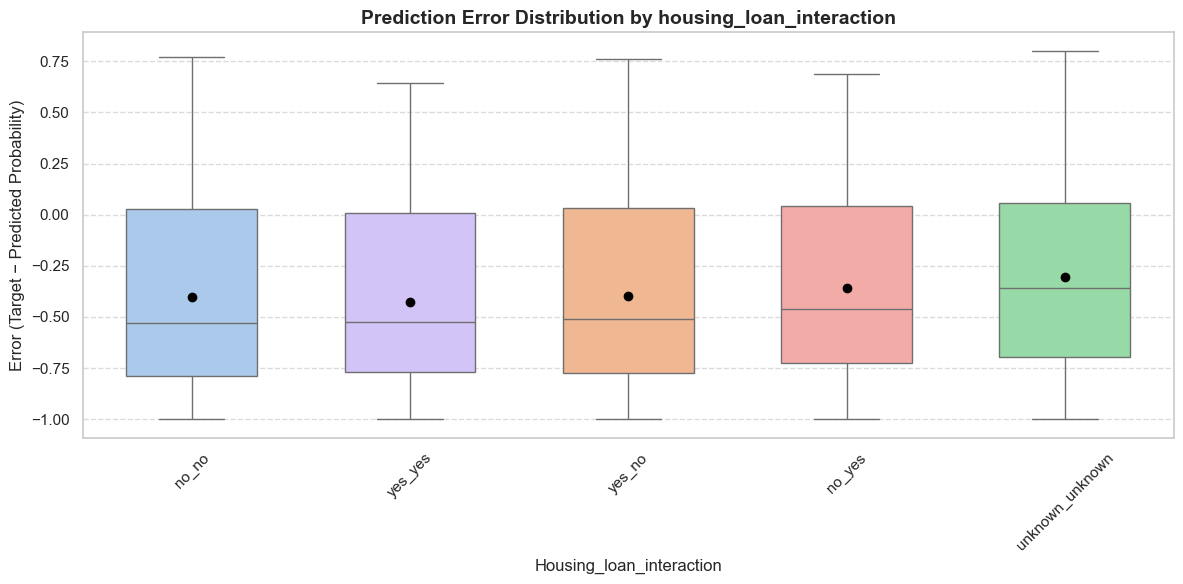

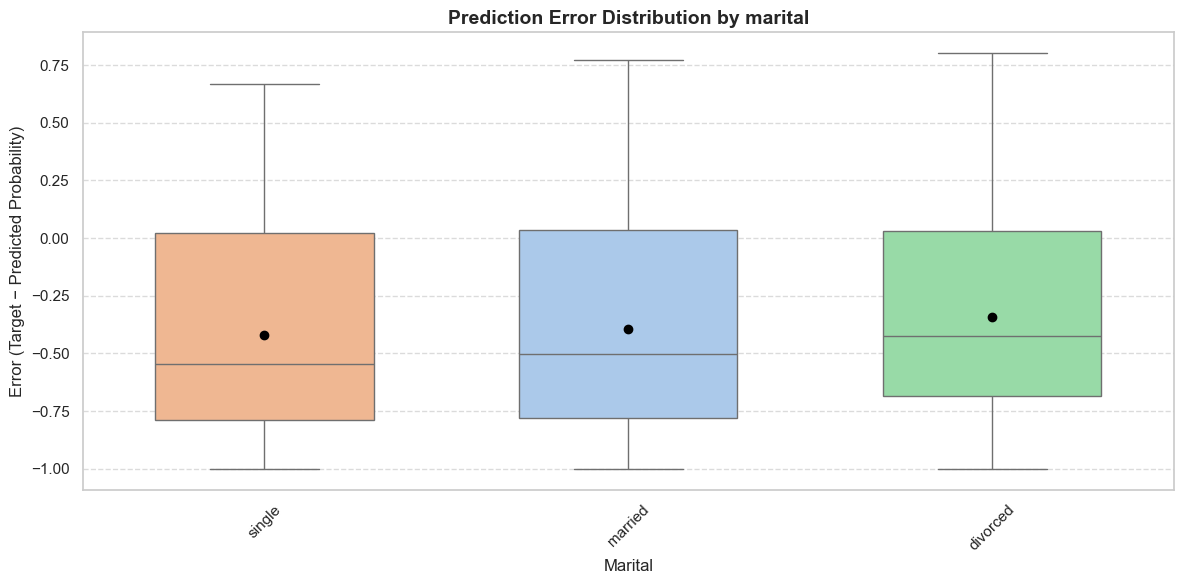

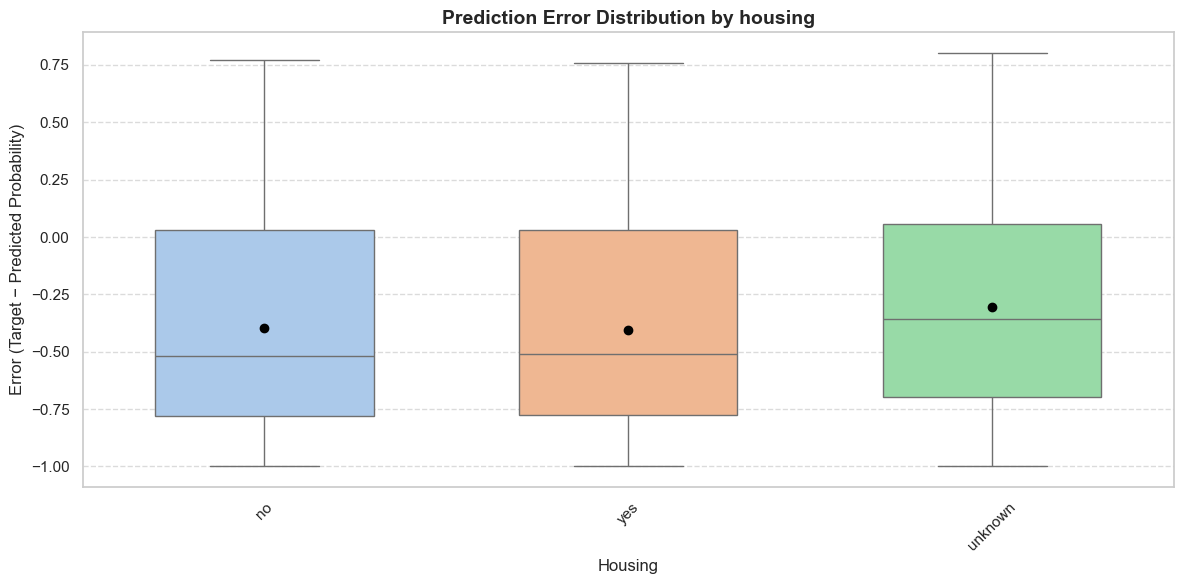

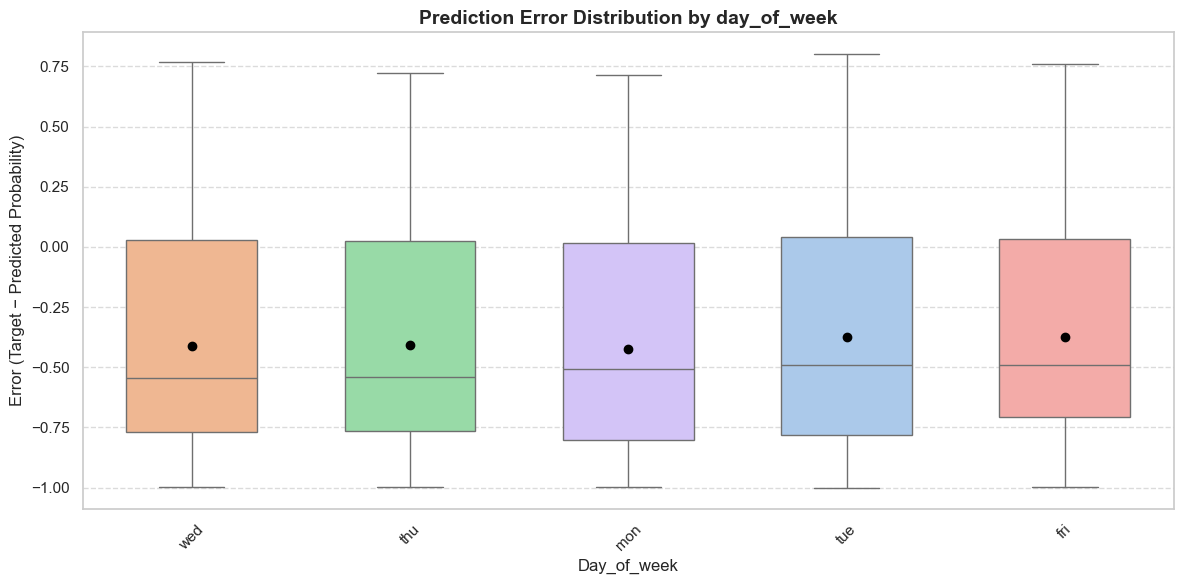

In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure save directory exists
save_dir = "Bank_Telemarketing_Prediction_EDSB25_1\reports\figures\categorical"
os.makedirs(save_dir, exist_ok=True)

# Identify categorical predictors present in the dataset
categorical_predictors = list(set(categorical_columns).intersection(set(error_df.columns)))

for categorical_predictor in categorical_predictors:
    # --- Print summary table ---
    summary = (
        error_df
        .groupby(categorical_predictor)["match"]
        .mean()
        .reset_index()
    )
    print(f"\nMatch rate by {categorical_predictor}:")
    print(summary.to_string(index=False))

    # --- Order categories by median error for clarity ---
    order = (
        error_df.groupby(categorical_predictor)["diff"]
        .median()
        .sort_values()
        .index
    )

    # --- Polished boxplot ---
    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=error_df,
        x=categorical_predictor,
        y="diff",
        hue=categorical_predictor,
        order=order,
        palette="pastel",
        width=0.6,
        showmeans=True,
        meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black"}
    )

    plt.title(f"Prediction Error Distribution by {categorical_predictor}", fontsize=14, weight="bold")
    plt.ylabel("Error (Target − Predicted Probability)")
    plt.xlabel(categorical_predictor.capitalize())
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()



    save_path = os.path.join(save_dir, f"{categorical_predictor}_error_analysis.png")
    plt.savefig(save_path, dpi=300)   # dpi=300 for high quality

In [ ]:

numerical_predictors = list(set(numerical_columns).intersection(set(error_df.columns)))


In [ ]:
for numerical_predictor in numerical_predictors:
    # --- Print summary table ---
    summary = (
        error_df
        .groupby(numerical_predictor)["match"]
        .mean()
        .reset_index()
    )
    print(f"\nMatch rate by {numerical_predictor}:")
    print(summary.to_string(index=False))
    
    
    


Match rate by predicted:
 predicted    match
         0 0.880403
         1 0.367585

Match rate by target:
 target    match
      0 0.233162
      1 0.933653

Match rate by diff:
     diff  match
-0.999898    0.0
-0.999723    0.0
-0.999698    0.0
-0.999682    0.0
-0.999679    0.0
-0.999662    0.0
-0.999649    0.0
-0.999638    0.0
-0.999627    0.0
-0.999617    0.0
-0.999614    0.0
-0.999612    0.0
-0.999610    0.0
-0.999602    0.0
-0.999593    0.0
-0.999568    0.0
-0.999548    0.0
-0.999531    0.0
-0.999512    0.0
-0.999503    0.0
-0.999494    0.0
-0.999493    0.0
-0.999485    0.0
-0.999479    0.0
-0.999469    0.0
-0.999433    0.0
-0.999366    0.0
-0.999359    0.0
-0.999349    0.0
-0.999291    0.0
-0.999254    0.0
-0.999244    0.0
-0.999227    0.0
-0.999197    0.0
-0.999192    0.0
-0.999135    0.0
-0.999116    0.0
-0.999048    0.0
-0.998936    0.0
-0.998927    0.0
-0.998915    0.0
-0.998864    0.0
-0.998856    0.0
-0.998855    0.0
-0.998809    0.0
-0.998804    0.0
-0.998792    0.0
-0.

ValueError: cannot insert match, already exists

In [ ]:
error_analysis_loop(error_df, numerical_columns, target_col="match", error_col="diff", save_dir="../reports/figures")


Match rate by age:
 age    match
  17 0.400000
  18 0.541667
  19 0.444444
  20 0.476190
  21 0.384615
  22 0.507042
  23 0.364486
  24 0.395604
  25 0.363636
  26 0.429864
  27 0.360595
  28 0.420495
  29 0.397759
  30 0.407166
  31 0.455090
  32 0.403955
  33 0.440217
  34 0.441088
  35 0.378277
  36 0.453125
  37 0.504237
  38 0.477612
  39 0.494253
  40 0.500000
  41 0.591716
  42 0.573427
  43 0.555556
  44 0.595041
  45 0.507812
  46 0.601626
  47 0.500000
  48 0.619048
  49 0.490196
  50 0.511364
  51 0.480392
  52 0.504348
  53 0.482759
  54 0.438095
  55 0.477778
  56 0.484848
  57 0.500000
  58 0.394495
  59 0.551020
  60 0.461538
  61 0.491525
  62 0.431034
  63 0.288889
  64 0.441860
  65 0.526316
  66 0.613636
  67 0.409091
  68 0.413793
  69 0.423077
  70 0.457143
  71 0.441860
  72 0.466667
  73 0.407407
  74 0.533333
  75 0.444444
  76 0.545455
  77 0.666667
  78 0.500000
  79 0.461538
  80 0.653846
  81 0.400000
  82 0.625000
  83 0.500000
  84 0.428571
  85 0.600000
